# Practical Exam - Set B
## Part B - Python Programming

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('employee_performance.csv')
print(df.shape)
print(df.head())


(4000, 8)
  Employee_ID  Department  ...  Performance_Score  Promotion_Status
0     EMP0001          IT  ...               65.2                No
1     EMP0002   Marketing  ...               78.3                No
2     EMP0003          IT  ...               74.6                No
3     EMP0004  Operations  ...               75.6               Yes
4     EMP0005     Finance  ...               75.0                No

[5 rows x 8 columns]


### Step 1: Central Tendency and Dispersion

In [2]:
mean_salary = df['Salary'].mean()
median_salary = df['Salary'].median()
mode_salary = df['Salary'].mode().iloc[0]

projects_range = df['Projects_Completed'].max() - df['Projects_Completed'].min()
projects_variance = df['Projects_Completed'].var(ddof=1)
projects_std = df['Projects_Completed'].std(ddof=1)

print('Mean Salary:', round(mean_salary, 2))
print('Median Salary:', round(median_salary, 2))
print('Mode Salary:', mode_salary)
print('Projects Range:', projects_range)
print('Projects Variance:', round(projects_variance, 4))
print('Projects Standard Deviation:', round(projects_std, 4))


Mean Salary: 956226.75
Median Salary: 955000.0
Mode Salary: 966000
Projects Range: 15
Projects Variance: 6.6731
Projects Standard Deviation: 2.5832


### Step 2: Probability and Events

In [3]:
p_promoted = (df['Promotion_Status'] == 'Yes').mean()
print('Probability of Promotion:', round(p_promoted, 4))

contingency = pd.crosstab(df['Department'], df['Promotion_Status'])
print(contingency)

high_score = df['Performance_Score'] > 80
p_promo_high = ((df['Promotion_Status'] == 'Yes') & high_score).sum() / high_score.sum()
print('Employees with score > 80:', int(high_score.sum()))
print('P(Promotion | Performance_Score > 80):', round(p_promo_high, 4))


Probability of Promotion: 0.3905
Promotion_Status   No  Yes
Department                
Finance           387  320
HR                318   86
IT                409  439
Marketing         384  199
Operations        494  196
Sales             446  322
Employees with score > 80: 1055
P(Promotion | Performance_Score > 80): 0.6834


### Step 3: Distributions and Visualization

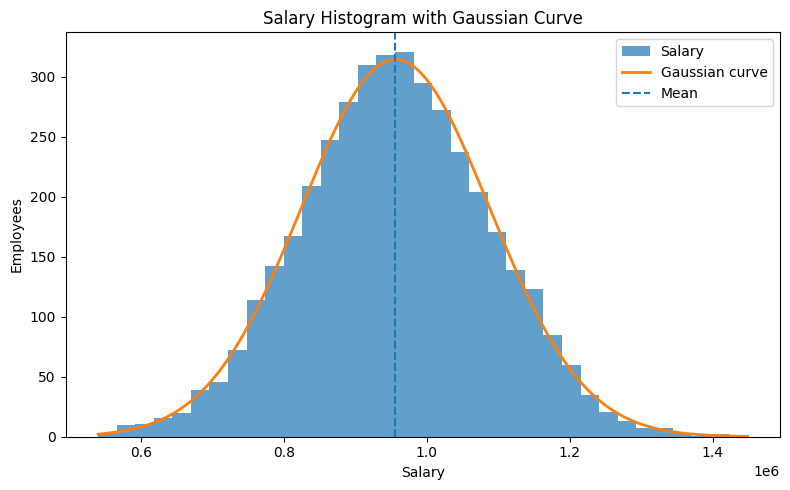

In [4]:
salary = df['Salary']
mu = salary.mean()
sigma = salary.std(ddof=1)
x = np.linspace(salary.min(), salary.max(), 400)
y = stats.norm.pdf(x, mu, sigma)
bins = 35
bin_width = (salary.max() - salary.min()) / bins

plt.figure(figsize=(8,5))
plt.hist(salary, bins=bins, alpha=0.7, label='Salary')
plt.plot(x, y * len(df) * bin_width, linewidth=2, label='Gaussian curve')
plt.axvline(mu, linestyle='--', linewidth=1.5, label='Mean')
plt.xlabel('Salary')
plt.ylabel('Employees')
plt.title('Salary Histogram with Gaussian Curve')
plt.legend()
plt.tight_layout()
plt.savefig('screenshots/01_salary_histogram_gaussian.png', dpi=150)
plt.show()


In [5]:
salary_skewness = df['Salary'].skew()
salary_kurtosis = df['Salary'].kurt()
print('Salary Skewness:', round(salary_skewness, 4))
print('Salary Kurtosis (excess):', round(salary_kurtosis, 4))


Salary Skewness: 0.0177
Salary Kurtosis (excess): -0.0227


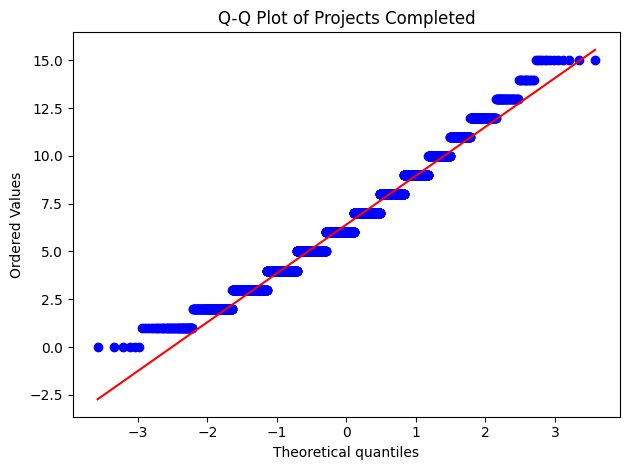

In [6]:
stats.probplot(df['Projects_Completed'], dist='norm', plot=plt)
plt.title('Q-Q Plot of Projects Completed')
plt.tight_layout()
plt.savefig('screenshots/04_projects_qqplot.png', dpi=150)
plt.show()


### Step 4: Linear Algebra Application

In [7]:
work = df.loc[:4, ['Employee_ID', 'Projects_Completed', 'Working_Hours']].copy()
print(work.to_string(index=False))

v1 = work.loc[0, ['Projects_Completed', 'Working_Hours']].to_numpy(dtype=float)
v2 = work.loc[1, ['Projects_Completed', 'Working_Hours']].to_numpy(dtype=float)

dot_product = np.dot(v1, v2)
v1_norm1 = np.linalg.norm(v1, ord=1)
v1_norm2 = np.linalg.norm(v1, ord=2)
v2_norm1 = np.linalg.norm(v2, ord=1)
v2_norm2 = np.linalg.norm(v2, ord=2)
angle = np.degrees(np.arccos(np.clip(dot_product / (v1_norm2 * v2_norm2), -1, 1)))

print('v1 =', v1)
print('v2 =', v2)
print('Dot product =', round(dot_product, 4))
print('v1 Norm-1 =', round(v1_norm1, 4))
print('v1 Norm-2 =', round(v1_norm2, 4))
print('v2 Norm-1 =', round(v2_norm1, 4))
print('v2 Norm-2 =', round(v2_norm2, 4))
print('Angle =', round(angle, 4), 'degrees')


Employee_ID  Projects_Completed  Working_Hours
    EMP0001                   5           44.7
    EMP0002                   6           38.4
    EMP0003                   6           42.5
    EMP0004                   4           48.0
    EMP0005                   5           37.6
v1 = [ 5.  44.7]
v2 = [ 6.  38.4]
Dot product = 1746.48
v1 Norm-1 = 49.7
v1 Norm-2 = 44.9788
v2 Norm-1 = 44.4
v2 Norm-2 = 38.8659
Angle = 2.4983 degrees


### Key observations

In [8]:
print('1. Overall promotion probability =', round(p_promoted * 100, 2), '%')
print('2. Promotion probability for score > 80 =', round(p_promo_high * 100, 2), '%')
rates = df.groupby('Department')['Promotion_Status'].apply(lambda s: (s == 'Yes').mean()).sort_values(ascending=False)
print('3. Highest department promotion rate =', rates.index[0], round(rates.iloc[0] * 100, 2), '%')
print('4. Highest average performance =', df.groupby('Department')['Performance_Score'].mean().idxmax())
print('5. Salary skewness =', round(salary_skewness, 4))


1. Overall promotion probability = 39.05 %
2. Promotion probability for score > 80 = 68.34 %
3. Highest department promotion rate = IT 51.77 %
4. Highest average performance = IT
5. Salary skewness = 0.0177
